In [1]:
import pandas as pd
titanic = pd.read_csv('titanic.csv')

In [ ]:
# Aggregation - group by category
# df[["col1", "col2"]].groupby("col1").mean()
sex_age_mean = titanic[["Sex", "Age"]].groupby("Sex").mean()
print(sex_age_mean)

              Age
Sex              
female  27.915709
male    30.726645


In [4]:
pclass_survived_mean = titanic[["Pclass", "Survived"]].groupby("Pclass").mean()
print(pclass_survived_mean)

        Survived
Pclass          
1       0.629630
2       0.472826
3       0.242363


In [ ]:
sex_mean = titanic.groupby("Sex").mean(numeric_only=True)
print(sex_mean)

# titanic.groupby("Sex").mean() will cause error because the "Sex" column is not numeric. 
# To avoid this, we can use the numeric_only=True parameter to only include numeric columns

        PassengerId  Survived    Pclass        Age     SibSp     Parch  \
Sex                                                                      
female   431.028662  0.742038  2.159236  27.915709  0.694268  0.649682   
male     454.147314  0.188908  2.389948  30.726645  0.429809  0.235702   

             Fare  
Sex                
female  44.479818  
male    25.523893  


In [ ]:
class_count = titanic["Pclass"].value_counts()
print(class_count)

# value_counts() returns a Series containing counts of unique values. 
# The resulting object will be in descending order so that the first element is the most frequently-occurring element.
# value_counts() is different from count() because count() returns the number of non-null values in a column, while value_counts() returns the counts of unique values in a column.

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [9]:
class_count = titanic["Pclass"].count()
print(class_count)

891


In [ ]:
class_count = titanic["Pclass"].value_counts().sort_index()
print(class_count)

# use sort_index() to sort the INDEX of the resulting Series in ascending order.

Pclass
1    216
2    184
3    491
Name: count, dtype: int64


In [11]:
# number of passengers with known cabin information
cabin_count = titanic["Cabin"].count()
print(cabin_count)

204


In [14]:
count_by_cabin = titanic["Cabin"].value_counts()
print(count_by_cabin)

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64


## MATPLOTLIB

In [ ]:
"""
Syntax
df.plot()
plt.show()
"""

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('titanic.csv')
print(df.head(10))


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54

In [ ]:

# Fill missing values in the 'Age' column with the mean age
df.fillna({'Age': df['Age'].mean()}, inplace=True)
# df['Age'].fillna(df['Age'].mean(), inplace=True) 
# This does not work - fillna method applies on the copy
print(df.head(10))


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex        Age  \
0                            Braund, Mr. Owen Harris    male  22.000000   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.000000   
2                             Heikkinen, Miss. Laina  female  26.000000   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.000000   
4                           Allen, Mr. William Henry    male  35.000000   
5                                   Moran, Mr. James    male  29.699118   
6                            McCarthy, Mr. Timothy J    male  54.000000   
7  

/var/folders/9x/cqwzwv3n71g0xrj8bv8bz74r0000gn/T/ipykernel_8975/2540529715.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].mean(), inplace=True)


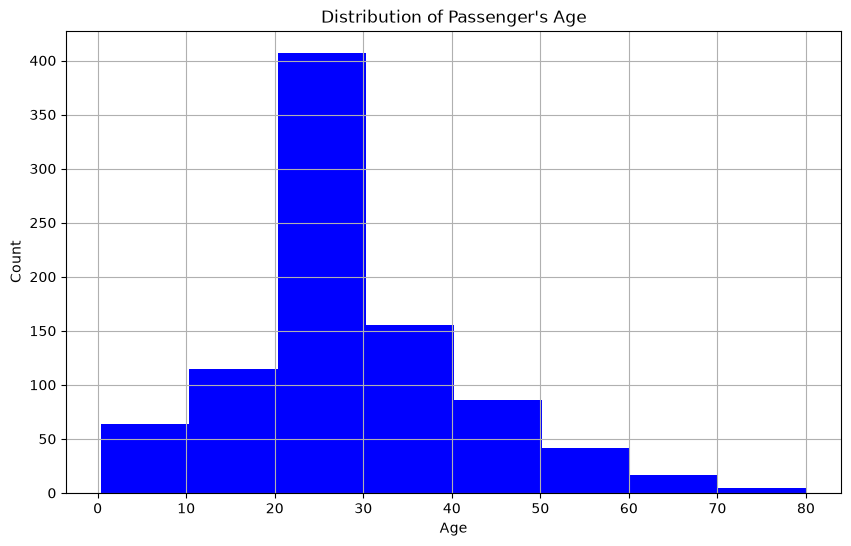

In [21]:
# Create a histogram of Age
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=8, color='b')
plt.title('Distribution of Passenger\'s Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(True)
plt.show()

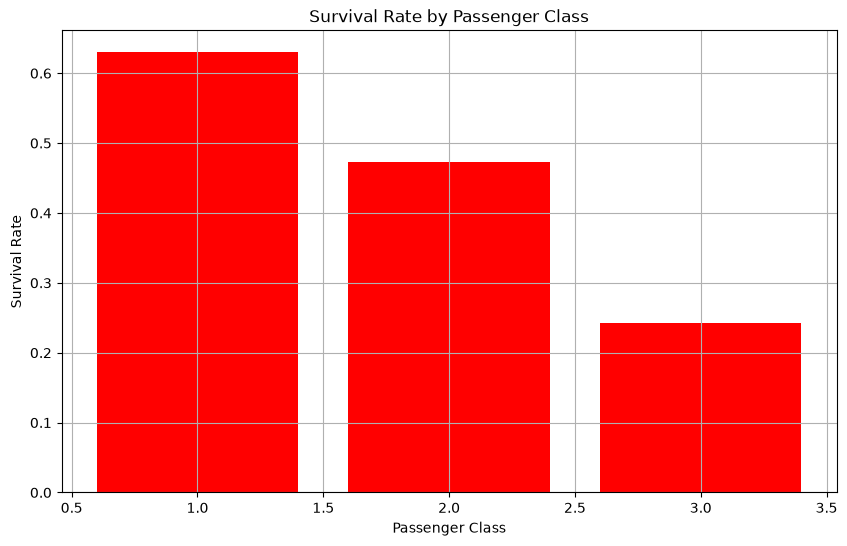

In [23]:
survival_by_class = df.groupby('Pclass')['Survived'].mean()
plt.figure(figsize=(10, 6))
plt.bar(survival_by_class.index, survival_by_class.values, color='red')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.grid(True)
plt.show()

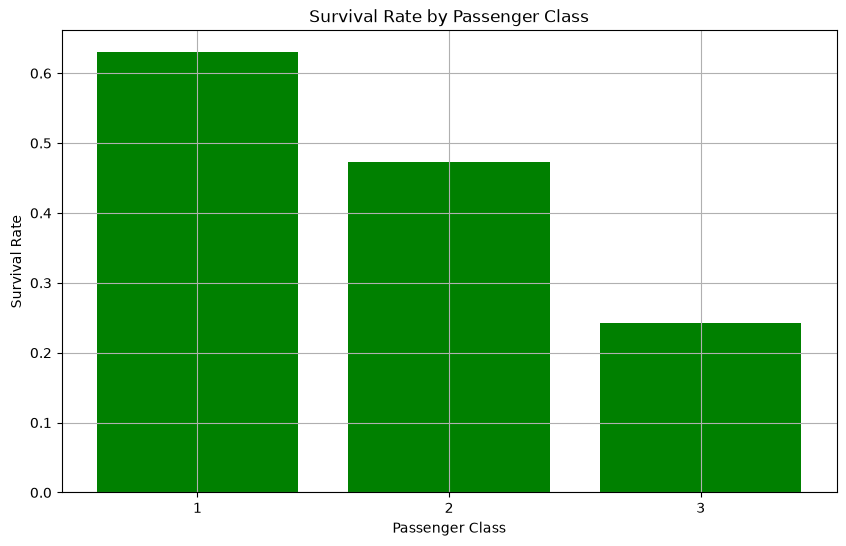

In [25]:
# show passenger class as 1, 2, 3 on x-axis

survival_by_class = df.groupby('Pclass')['Survived'].mean()
plt.figure(figsize=(10, 6))
plt.bar(survival_by_class.index, survival_by_class.values, color='g')
plt.xticks([1, 2, 3])  # Set x-ticks to show passenger class as 1, 2, 3
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.grid(True)
plt.show()

In [28]:
max_age = df['Age'].max()
min_age = df['Age'].min()
print(f"Max Age: {max_age}, Min Age: {min_age}")

Max Age: 80.0, Min Age: 0.42


In [ ]:
# Find the name of the oldest passenger
print(df.loc[df['Age'].idxmax(), 'Name'])

Barkworth, Mr. Algernon Henry Wilson


In [34]:
oldest_label = df['Age'].idxmax()
print(oldest_label)

630


In [33]:
df['family_members'] = df['SibSp'] + df['Parch']
df['family_members'].value_counts().sort_index()

family_members
0     537
1     161
2     102
3      29
4      15
5      22
6      12
7       6
10      7
Name: count, dtype: int64